In [24]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
import IPython.display as ipd

In [25]:
# Charger un exemple audio intégré (parole humaine)
sample_path = librosa.example('choice')
signal, sr = librosa.load(sample_path, sr=16000)

# Garder 10 secondes max
signal = signal[:10 * sr]

# Ajouter du bruit blanc
noise = np.random.normal(0, 0.05, signal.shape)
noisy_signal = signal + noise

# Normalisation entre -1 et 1
signal = signal / np.max(np.abs(signal))
noisy_signal = noisy_signal / np.max(np.abs(noisy_signal))

# Découper en trames (2048 échantillons avec recouvrement)
frame_length = 2048
hop_length = 1024

def frame_signal(sig):
    return librosa.util.frame(sig, frame_length=frame_length, hop_length=hop_length).T

X_clean = frame_signal(signal)
X_noisy = frame_signal(noisy_signal)

# Mise en forme pour Conv1D : (nb_samples, time_steps, channels)
X_clean = X_clean[..., np.newaxis]
X_noisy = X_noisy[..., np.newaxis]

# Séparation en train/test
X_train, X_test, Xn_train, Xn_test = train_test_split(X_noisy, X_clean, test_size=0.2, random_state=42)

In [26]:
input_layer = Input(shape=(frame_length, 1))

x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(input_layer)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)

In [27]:
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(1, kernel_size=3, activation='tanh', padding='same')(x)

In [28]:
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 2048, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 1024, 8)        │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 512, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 512, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 256, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 256, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_9 (UpSampling1D)  │ (None, 512, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 512, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_10 (UpSampling1D) │ (None, 1024, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 1024, 16)       │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_11 (UpSampling1D) │ (None, 2048, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 2048, 1)        │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = autoencoder.fit(
    X_train, Xn_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Xn_test),
    verbose=1
)


Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 599ms/step - loss: 0.0133 - val_loss: 0.0124
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.0125 - val_loss: 0.0119
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - loss: 0.0106 - val_loss: 0.0114
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - loss: 0.0110 - val_loss: 0.0108
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - loss: 0.0104 - val_loss: 0.0100
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0085 - val_loss: 0.0086
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0084 - val_loss: 0.0078
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0074 - val_loss: 0.0069
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.0067 - val_loss: 0.0062
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0057 - val_loss: 0.0056
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.0

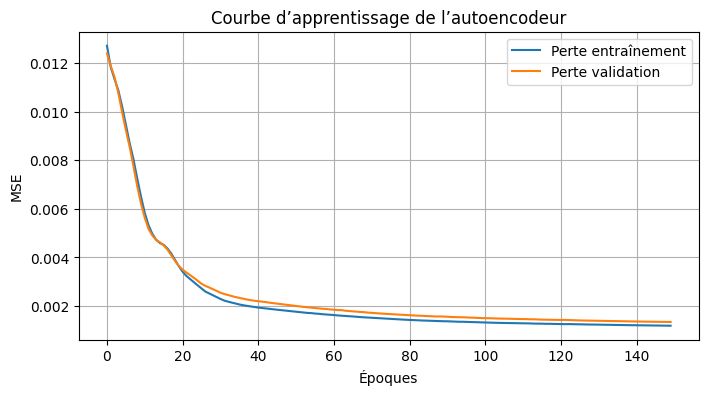

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Perte entraînement')
plt.plot(history.history['val_loss'], label='Perte validation')
plt.xlabel("Époques")
plt.ylabel("MSE")
plt.title("Courbe d’apprentissage de l’autoencodeur")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Reconstruction
Xn_denoised = autoencoder.predict(X_noisy)

# Fonction pour recoller les trames audio
def overlap_add(frames, hop_length):
    output_length = (len(frames) - 1) * hop_length + frames.shape[1]
    output = np.zeros(output_length)
    for i, frame in enumerate(frames):
        output[i*hop_length:i*hop_length+frame_length] += frame[:, 0]
    return output

reconstructed_signal = overlap_add(Xn_denoised, hop_length)

# Normalisation finale
reconstructed_signal /= np.max(np.abs(reconstructed_signal))

# Écoute des signaux
print("🔊 Signal propre (référence) :")
ipd.display(ipd.Audio(signal, rate=sr))

print("🔊 Signal bruité :")
ipd.display(ipd.Audio(noisy_signal, rate=sr))

print("🔊 Signal filtré (reconstruit par autoencodeur) :")
ipd.display(ipd.Audio(reconstructed_signal, rate=sr))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
🔊 Signal propre (référence) :


🔊 Signal bruité :


🔊 Signal filtré (reconstruit par autoencodeur) :
